# Introduction

This project analyzes the Reddit JODIE dataset, a temporal network containing approximately 672,000 interactions between 10,000 users and 1,000 subreddits over a one-month period. Unlike static graphs, these interactions occur over time, allowing both structural and temporal aspects of the network to be examined.

The first part of the project applies network science techniques to investigate graph topology, connectivity, community structure, resilience, and temporal evolution. The second part explores Temporal Graph Networks (TGN) introduced by E. Rossi et al. in the paper [Temporal Graph Networks for Deep Learning on Dynamic Graphs](https://arxiv.org/pdf/2006.10637).
In this notebook, TGN is used for dynamic link prediction, demonstrating how time-aware models can capture patterns that static network analysis cannot.

The objective is to understand how network structure emerges from temporal interactions and to evaluate the benefits of temporal graph learning in dynamic environments.

# Installs & Imports

In [ ]:
!pip uninstall -y community
!pip install python-louvain
!pip install powerlaw
!pip install torch_geometric

import torch
from sklearn.metrics import average_precision_score, roc_auc_score
from torch.nn import Linear
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import networkx as nx
import community.community_louvain as community_louvain
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import random
import powerlaw
from torch_geometric.datasets import JODIEDataset
from torch_geometric.loader import TemporalDataLoader
from torch_geometric.nn import TGNMemory, TransformerConv
from torch_geometric.nn.models.tgn import (
  IdentityMessage,
  LastAggregator,
  LastNeighborLoader,
)

Found existing installation: community 1.0.0b1
Uninstalling community-1.0.0b1:
  Successfully uninstalled community-1.0.0b1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.0/192.0 kB 8.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 38.1 MB/s eta 0:00:00


# Dataset Exploration

In [ ]:
dataset = JODIEDataset("/content", name='reddit')
data = dataset[0]

print("Data Object:", data)

Processing...
Done!


Data Object: TemporalData(src=[672447], dst=[672447], t=[672447], msg=[672447, 172], y=[672447])


## Dataset Structure

In [ ]:
raw_csv_path = '/content/reddit/raw/reddit.csv'

# Defining all 176 column names: 4 metadata columns + 172 feature columns
col_names = ['user_id', 'item_id', 'timestamp', 'state_label'] + [f'feat_{i}' for i in range(172)]

# Loading with comma separator and explicit names
raw_df = pd.read_csv(raw_csv_path, sep=',', names=col_names, header=0)

print(f"Raw CSV shape: {raw_df.shape}")
display(raw_df.head())

Raw CSV shape: (672447, 176)


,user_id,item_id,timestamp,state_label,feat_0,feat_1,feat_2,feat_3,feat_4,feat_5,...,feat_162,feat_163,feat_164,feat_165,feat_166,feat_167,feat_168,feat_169,feat_170,feat_171
0,0,0,0.000,0,-0.066606,-0.085004,0.295094,-0.137413,0.633033,0.230892,...,-0.138121,-0.121915,-0.089435,-0.201008,-0.04889,-0.06607,-0.075544,-0.124070,-0.088269,-0.127964
1,1,1,6.320,0,-0.984346,-0.952931,0.799396,-0.441921,0.138269,-1.247699,...,-0.138121,-0.121915,-0.089435,-0.201008,-0.04889,-0.06607,-0.075544,-0.124070,-0.088269,-0.127964
2,2,2,7.026,0,0.402936,0.400013,-0.707927,0.445288,-0.470656,0.106546,...,-0.138121,0.409055,-0.089435,1.006978,-0.04889,-0.06607,-0.075544,3.105280,-0.088269,2.851253
3,3,2,13.599,0,0.744421,0.706341,-1.305477,0.854593,0.459962,0.310579,...,-0.138121,0.409055,-0.089435,2.214963,-0.04889,-0.06607,-0.075544,9.563979,-0.088269,-0.127964
4,4,3,16.811,0,-0.386748,-0.391331,-1.159318,0.783032,0.778826,0.087158,...,0.410609,5.187780,-0.089435,-0.201008,-0.04889,-0.06607,-0.075544,-0.124070,-0.088269,-0.127964


(array([16530., 28679., 35713., 36673., 41563., 46473., 57665., 47728.,
        46820., 46352., 41482., 36544., 36415., 22937., 18965., 16069.,
        12528., 10094.,  9634.,  6675.,  5949.,  5358.,  5293.,  4010.,
         4286.,  3066.,  2467.,  2139.,  1895.,  1845.,  1587.,  1872.,
         1412.,  1325.,  1279.,  1098.,  1043.,  1103.,   839.,   961.,
          831.,   788.,   686.,   856.,   817.,   728.,   825.,  1132.,
         1331.,    87.]),
 array([-1.32583082, -1.19435918, -1.06288755, -0.93141586, -0.79994422,
        -0.66847259, -0.53700089, -0.40552926, -0.27405763, -0.14258599,
        -0.01111436,  0.12035728,  0.25182903,  0.38330066,  0.5147723 ,
         0.64624393,  0.77771556,  0.9091872 ,  1.04065883,  1.17213047,
         1.3036021 ,  1.43507373,  1.56654537,  1.698017  ,  1.82948887,
         1.96096051,  2.09243202,  2.22390366,  2.35537529,  2.48684692,
         2.61831856,  2.74979019,  2.88126183,  3.01273346,  3.14420509,
         3.27567673,  3.4071483

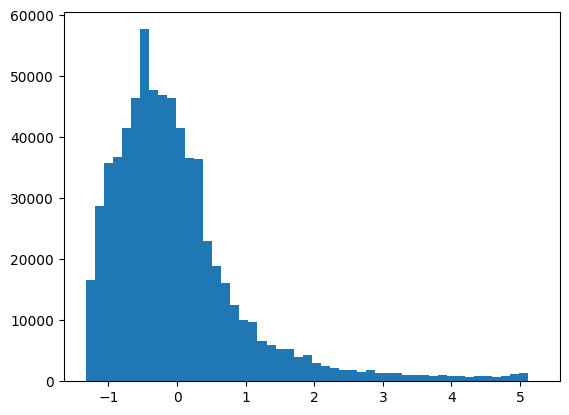

In [ ]:
features = data.msg.numpy()
pd.DataFrame(features).describe()
plt.hist(features[:,0], bins=50)

The interaction attributes consist of 172 numerical content features associated with each Reddit interaction. These features provide semantic and psycholinguistic information extracted from the interaction content and complement the structural information contained in the temporal network. Inspection of the feature distributions indicates that many dimensions are approximately centered around zero, suggesting that the features have undergone preprocessing or normalization prior to release.

In [ ]:
# Convert the TemporalData to a pandas DataFrame for easier manipulation
df = pd.DataFrame({
    'src': data.src.numpy(),
    'dst': data.dst.numpy(),
    't': data.t.numpy(),
    'y': data.y.numpy()
})

df.head()

,src,dst,t,y
0,0,10000,0,0
1,1,10001,6,0
2,2,10002,7,0
3,3,10002,13,0
4,4,10003,16,0


The Reddit dataset is represented as a bipartite interaction network.
User nodes occupy one index range while item/subreddit nodes occupy another.
Consequently, destination node identifiers begin at 10,000,
preventing overlap between user and item IDs.

In [ ]:
num_nodes = data.num_nodes
num_interactions = data.num_events
time_span_seconds = data.t.max() - data.t.min()
feature_dim = data.msg.size(1)

print(f"Number of nodes: {num_nodes}")
print(f"Number of interactions: {num_interactions}")
print(f"Time span: {time_span_seconds.item() / (3600 * 24):.2f} days")
print(f"Feature dimensions: {feature_dim}")

Number of nodes: 10984
Number of interactions: 672447
Time span: 31.00 days
Feature dimensions: 172


The JODIE Reddit dataset attributes are partitioned into metadata and learned representations:

*   **Relational Metadata**: `user_id` and `item_id` define the bipartite source-destination pairs, while `timestamp` provides the continuous temporal coordinate for each event. 10,000 most active users in 1000 most active subreddits were taken into this dataset.
*   **State Labels**: The `state_label` serves as a ground-truth indicator for interaction dynamics (e.g., indicating whether a user was banned following an interaction).
*   **Interaction Embeddings**: Columns `feat_0` through `feat_171` consist of 172-dimensional vector representations. These embeddings encapsulate the semantic content of the interaction, providing a high-dimensional feature space that allows models to capture complex behavioral patterns beyond simple graph topology.

Information regarding the dataset can be gathered from the dataset's creators and  authors of the paper [Predicting Dynamic Embedding Trajectory in
Temporal Interaction Networks](https://https://arxiv.org/pdf/1908.01207) that uses the same dataset: Srijan Kumar, Xikun Zhang, and Jure Leskovec. Even more information about the dataset can be found at the aforementioned paper.

## Label Distribution and Class Imbalance

Class Distribution:
0    672081
1       366
Name: count, dtype: int64


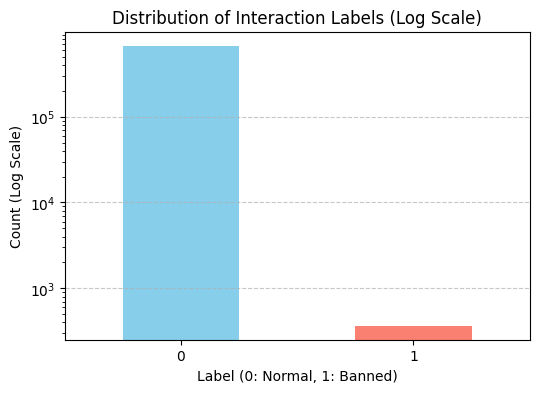

In [ ]:
label_counts = pd.Series(data.y.numpy()).value_counts().sort_index()

print("Class Distribution:")
print(label_counts)

plt.figure(figsize=(6, 4))
ax = label_counts.plot(kind='bar', color=['skyblue', 'salmon'])
plt.yscale('log')  # Use log scale to handle extreme class imbalance
plt.title('Distribution of Interaction Labels (Log Scale)')
plt.xlabel('Label (0: Normal, 1: Banned)')
plt.ylabel('Count (Log Scale)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Analysis of the `state_label` reveals a significant class imbalance within the dataset:

*   **Proportion of Positive States**: With only 366 positive instances ("banned" status) out of 672,447 total interactions, the positive class represents approximately 0.05% of the dataset.
*   **Implications for Modeling**: This extreme sparsity necessitates the use of specific performance metrics. Standard accuracy is misleading here, as a trivial model predicting "0" for every instance would achieve >99.9% accuracy. Consequently, when evaluating the TGN performance later, we must prioritize Average Precision (AP) and Area Under the ROC Curve (AUC-ROC), which better capture the model's ability to rank the rare positive events correctly amidst the vast majority of negative samples.

## Temporal Distribution Analysis

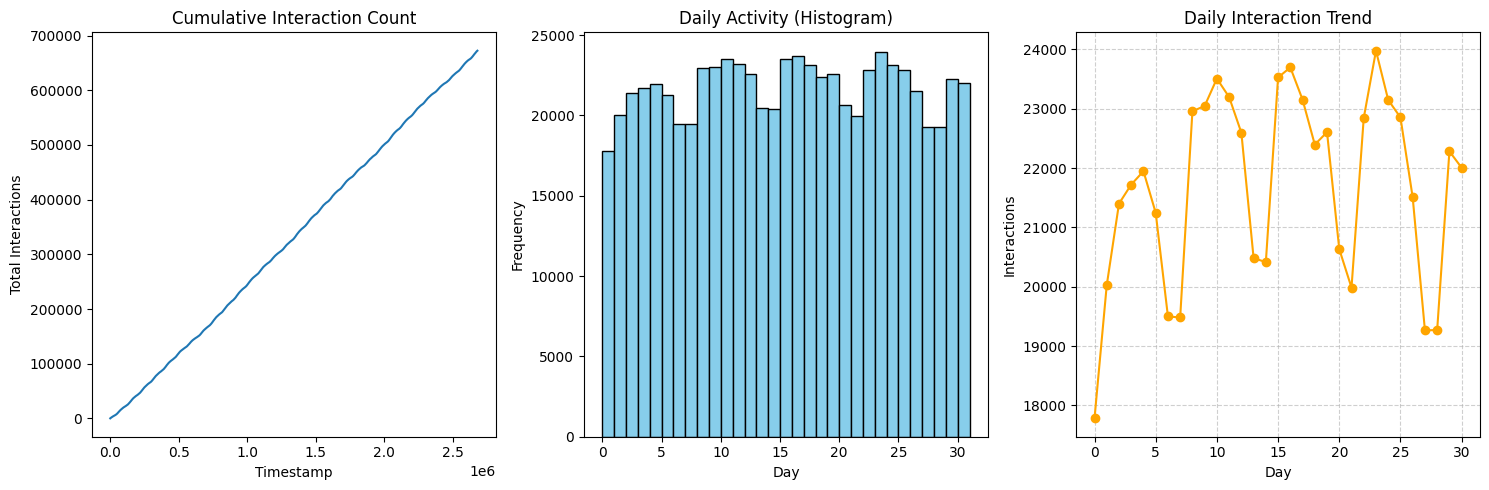

In [ ]:
times = data.t.numpy()
df['day'] = ((df['t'] - df['t'].min()) / (3600 * 24)).astype(int)
daily_counts = df.groupby('day').size()

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(np.sort(times), np.arange(len(times)))
plt.title('Cumulative Interaction Count')
plt.xlabel('Timestamp')
plt.ylabel('Total Interactions')

plt.subplot(1, 3, 2)
days_float = (times - times.min()) / (3600 * 24)
plt.hist(days_float, bins=31, color='skyblue', edgecolor='black')
plt.title('Daily Activity (Histogram)')
plt.xlabel('Day')
plt.ylabel('Frequency')

plt.subplot(1, 3, 3)
daily_counts.plot(kind='line', marker='o', color='orange')
plt.title('Daily Interaction Trend')
plt.xlabel('Day')
plt.ylabel('Interactions')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

The temporal visualizations confirm the structural stability of the Reddit dataset. The Cumulative Interaction Count follows a strictly linear trajectory, suggesting a constant global arrival rate of events. By discretizing the timeline into 24-hour windows, the Daily Interaction Trend reveals minor periodic fluctuations, yet the overall volume remains within a stable range (approximately 18k to 25k interactions per day). This stationarity is critical for training Temporal Graph Networks, as it ensures that the model encounters a consistent density of events throughout its memory update cycles without requiring complex normalization for extreme activity bursts.

# Graph Theory Fundamentals

This construction collapses temporal and repeated interactions into a static undirected graph, where multiple interactions between the same nodes are represented as a single edge.

In [ ]:
G = nx.Graph()

# We iterate through the source and destination pairs to build the topology
for s, d in zip(data.src.numpy(), data.dst.numpy()):
  G.add_edge(int(s), int(d))

nodes = G.number_of_nodes()
edges = G.number_of_edges()
density = nx.density(G)

print(f"Number of unique nodes: {nodes}")
print(f"Number of unique edges (static): {edges}")
print(f"Graph Density: {density:.6f}")

Number of unique nodes: 10984
Number of unique edges (static): 78516
Graph Density: 0.001302


The transformation of the temporal interaction stream into a static graph reveals a sparse network structure with a density of approximately 0.0013. This indicates that only a small fraction of all possible node pairs interact, which is typical of social interaction networks.

The static projection contains 78,516 unique edges, significantly fewer than the 672,447 temporal interactions, indicating repeated interactions over time between the same node pairs. This shows that edges (unique connections) $\not=$ events (repeated interactions) as well as the importance of temporal dynamics in the dataset.

## Degree Distribution Analysis

The degree of a node represents its total number of unique connections. In many real-world networks, we expect to see a "power-law" distribution, where a few "hub" nodes have very high degrees while most nodes have very few.

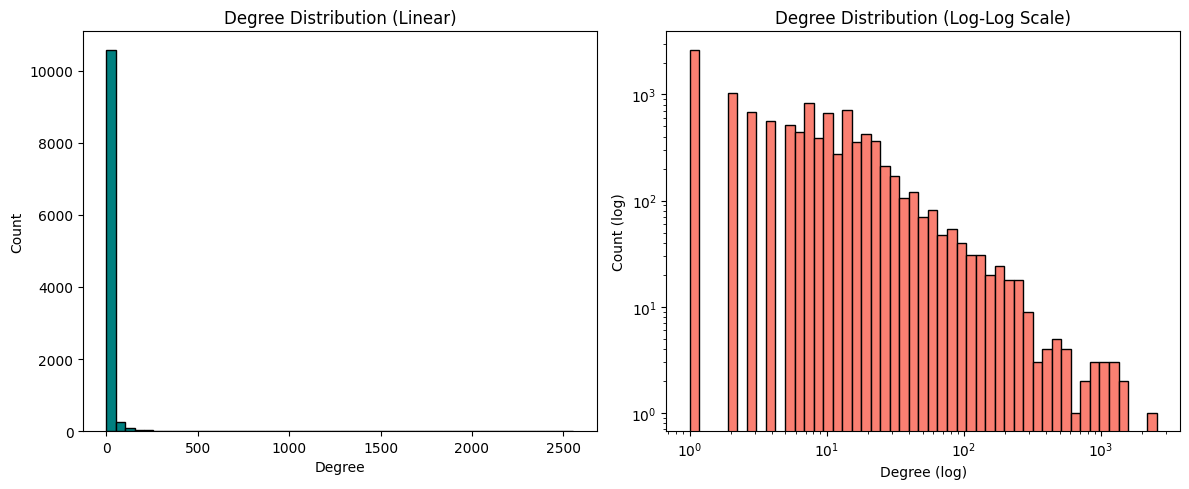

In [ ]:
degrees = [d for _, d in G.degree()]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(degrees, bins=50, color='teal', edgecolor='black')
plt.title('Degree Distribution (Linear)')
plt.xlabel('Degree')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
# Filter out zero degrees to avoid log errors if any
clean_degrees = [d for d in degrees if d > 0]
plt.hist(clean_degrees,
         bins=np.logspace(np.log10(min(clean_degrees)), np.log10(max(clean_degrees)), 50),
         color='salmon', edgecolor='black')
plt.gca().set_xscale("log")
plt.gca().set_yscale("log")
plt.title('Degree Distribution (Log-Log Scale)')
plt.xlabel('Degree (log)')
plt.ylabel('Count (log)')

plt.tight_layout()
plt.show()

The transition from a temporal stream to a static graph reveals several key topological properties of the Reddit interaction network:

*   **Sparsity and Density**: The large gap between total interactions (672,447) and unique edges (78,516) indicates that the network is driven by repeated interactions between the same pairs of nodes, rather than one-time connections. This is typical of social interaction networks where engagement is persistent over time.
*   **Degree Distribution**: The linear histogram shows a sharp 'long-tail' where the vast majority of nodes have a very low degree.
*   **Power-Law Dynamics**: The log-log degree distribution suggests a heavy-tailed structure, which is consistent with scale-free behavior. However, visual inspection alone is not sufficient to confirm a true power-law distribution, and statistical fitting would be required for rigorous validation.

Collapsing the temporal network into a static graph removes ordering information, which is crucial for understanding interaction dynamics. This motivates the use of temporal models such as TGN, which preserve event order.

# Network Measures and Metrics

In this section, we quantify the influence of individual nodes using various centrality measures. These metrics help identify the "structural backbone" of the network, i.e., nodes that are essential for connectivity or information dissemination.

In [ ]:
print("Computing centrality measures...")

deg_cent = nx.degree_centrality(G)
eig_cent = nx.eigenvector_centrality(G, max_iter=1000)

# For betweenness, we use a k-sample to speed up calculation on this medium-sized graph
bet_cent = nx.betweenness_centrality(G, k=100, seed=42)
clo_cent = nx.closeness_centrality(G)

# Identify top nodes for each metric
metrics = {
    "Degree Centrality": deg_cent,
    "Betweenness Centrality": bet_cent,
    "Closeness Centrality": clo_cent,
    "Eigenvector Centrality": eig_cent
}

top_nodes_data = []
for name, metric_dict in metrics.items():
  top_node = max(metric_dict, key=metric_dict.get)
  top_nodes_data.append({
      "Metric": name,
      "Top Node ID": top_node,
      "Value": metric_dict[top_node]
  })

centrality_df = pd.DataFrame(top_nodes_data)
display(centrality_df)

Computing centrality measures...


,Metric,Top Node ID,Value
0,Degree Centrality,10032,0.232632
1,Betweenness Centrality,10032,0.197725
2,Closeness Centrality,10032,0.407417
3,Eigenvector Centrality,10032,0.297386


A striking result is that all centrality measures identify the same node (ID 10032) as the most central in the network. This indicates an extremely centralized structure, where a single node dominates not only local connectivity but also global network flow and eigenvector influence.

*   **Degree Centrality**: The top node exhibits a degree centrality of 0.233, meaning it is directly connected to approximately 23% of all nodes in the network, highlighting an extremely high level of connectivity.
*   **Betweenness Centrality**: The same node also dominates betweenness centrality, indicating that it lies on a disproportionately large number of shortest paths. This suggests that the network's communication structure is heavily routed through a single hub, rather than distributed across multiple bridging nodes.
*   **Closeness Centrality**: High closeness centrality indicates that this node has, on average, shorter path distances to all other nodes in the network, reinforcing its structural centrality in the largest connected component.
*   **Eigenvector Centrality**: Eigenvector centrality emphasizes nodes connected to other highly connected nodes, suggesting that this node is embedded within the most densely connected region of the network. However, this centrality may be sensitive to the presence of dominant hubs in sparse networks, and should be interpreted alongside other centrality measures. Therefore the eigenvector centrality result should be taken with a grain of salt.

In [ ]:
all_same = len(set(top_nodes_data[i]["Top Node ID"] for i in range(len(top_nodes_data)))) == 1
print("All centralities are same:", all_same)

All centralities are same: True


All centrality measures identify the same node as the most central, indicating a strong structural hierarchy.

The strong agreement across multiple centrality measures suggests that local, global, and eigenvector-based notions of importance are aligned in this network.

## Top 10 Central Nodes

In [ ]:
top10_list = sorted(deg_cent.items(), key=lambda x: x[1], reverse=True)[:10]

top10_df = pd.DataFrame(top10_list, columns=['Node ID', 'Degree Centrality'])

print("Top 10 Most Central Nodes (Degree Centrality):")
display(top10_df)

Top 10 Most Central Nodes (Degree Centrality):


,Node ID,Degree Centrality
0,10032,0.232632
1,10019,0.142584
2,10072,0.141309
3,10054,0.118638
4,10031,0.114541
5,10092,0.112629
6,10002,0.099791
7,10006,0.098789
8,10015,0.095056
9,10176,0.088136


The Degree Centrality ranking confirms a steeply hierarchical structure within the Reddit interaction graph:

*   **Dominant Hub**: Node 10032 remains the singular dominant entity, with a centrality of 0.2326. This indicates it is a primary destination or source for nearly a quarter of all unique connections in the sampled network.
*   **Secondary Tier**: There is a significant drop-off between the top node and the next tier of hubs (Nodes 10019 and 10072, both ~0.14). This gap illustrates that while the network has multiple hubs, the distribution of influence is not uniform even among the most central nodes.
*   **Structural Significance**: These top 10 nodes effectively form the "core" of the bipartite graph. In the context of a TGN, these nodes act as massive information aggregators; their memory states are updated far more frequently than the average node, making them critical points for propagating influence and detecting global behavioral shifts (such as widespread banning patterns).

The structural properties suggest that node 10032 is likely associated with a high-activity subreddit, as such nodes typically exhibit high degree and serve as hubs in bipartite interaction networks. However, without access to the original ID mapping, we cannot definitively distinguish between user and subreddit identities.

# Connectivity and Components

Connectivity analysis helps us understand the global reach of the network. In social graphs, we typically observe a singular Largest Connected Component (LCC) that encompasses the majority of nodes, while peripheral nodes form small, disconnected clusters.

In [ ]:
components = list(nx.connected_components(G))
num_components = len(components)
component_sizes = [len(c) for c in components]

lcc_size = max(component_sizes)
lcc = max(nx.connected_components(G), key=len)
isolated_nodes = component_sizes.count(1)


print(f"Number of connected components: {num_components}")
print(f"Size of the LCC: {lcc_size} nodes ({lcc_size/nodes*100:.2f}% of graph)")
print(f"Number of isolated nodes: {isolated_nodes}")

Number of connected components: 3
Size of the LCC: 10980 nodes (99.96% of graph)
Number of isolated nodes: 0


## Visualizing All Components

There are exactly 3 connected components in the network. Below, we visualize all of them side-by-side to see the contrast between the massive interconnected core and the tiny isolated interactions.

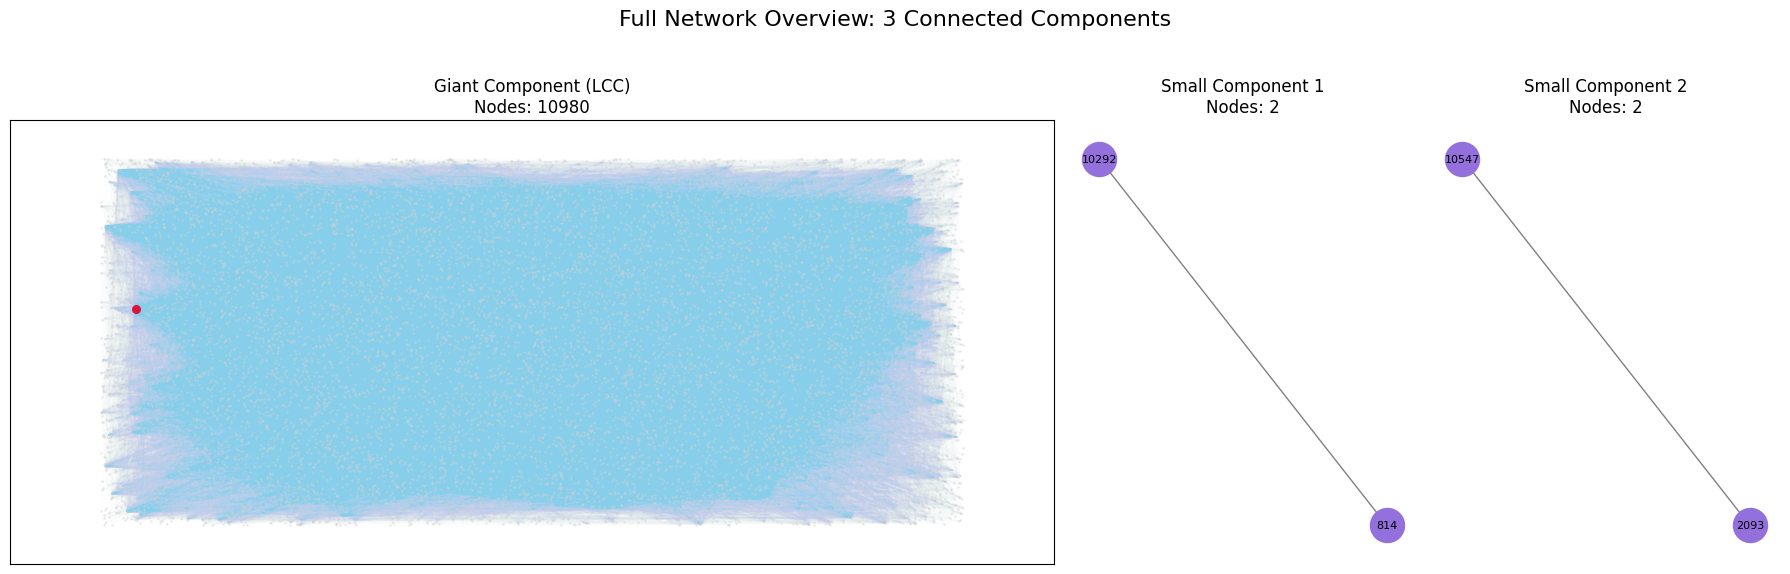

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), gridspec_kw={'width_ratios': [3, 1, 1]})

sorted_comps = sorted(nx.connected_components(G), key=len, reverse=True)

for i, comp in enumerate(sorted_comps):
  subgraph = G.subgraph(comp)
  ax = axes[i]

  if len(comp) > 100:
    # Visualizing the Giant Component with a random layout and small nodes
    pos = nx.random_layout(subgraph, seed=42)
    nx.draw_networkx_nodes(subgraph, pos, node_size=1, node_color='lightgray', alpha=0.3, ax=ax)
    nx.draw_networkx_nodes(subgraph, pos, nodelist=[10032], node_size=30, node_color='crimson', ax=ax)
    nx.draw_networkx_edges(subgraph, pos, alpha=0.01, edge_color='skyblue', ax=ax)
    ax.set_title(f"Giant Component (LCC)\nNodes: {len(comp)}")
  else:
    # Visualizing small islands with a standard layout
    pos = nx.spring_layout(subgraph, seed=42)
    nx.draw(subgraph, pos, with_labels=True, node_color='mediumpurple',
            edge_color='gray', node_size=600, font_size=8, ax=ax)
    ax.set_title(f"Small Component {i}\nNodes: {len(comp)}")

plt.suptitle("Full Network Overview: 3 Connected Components", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

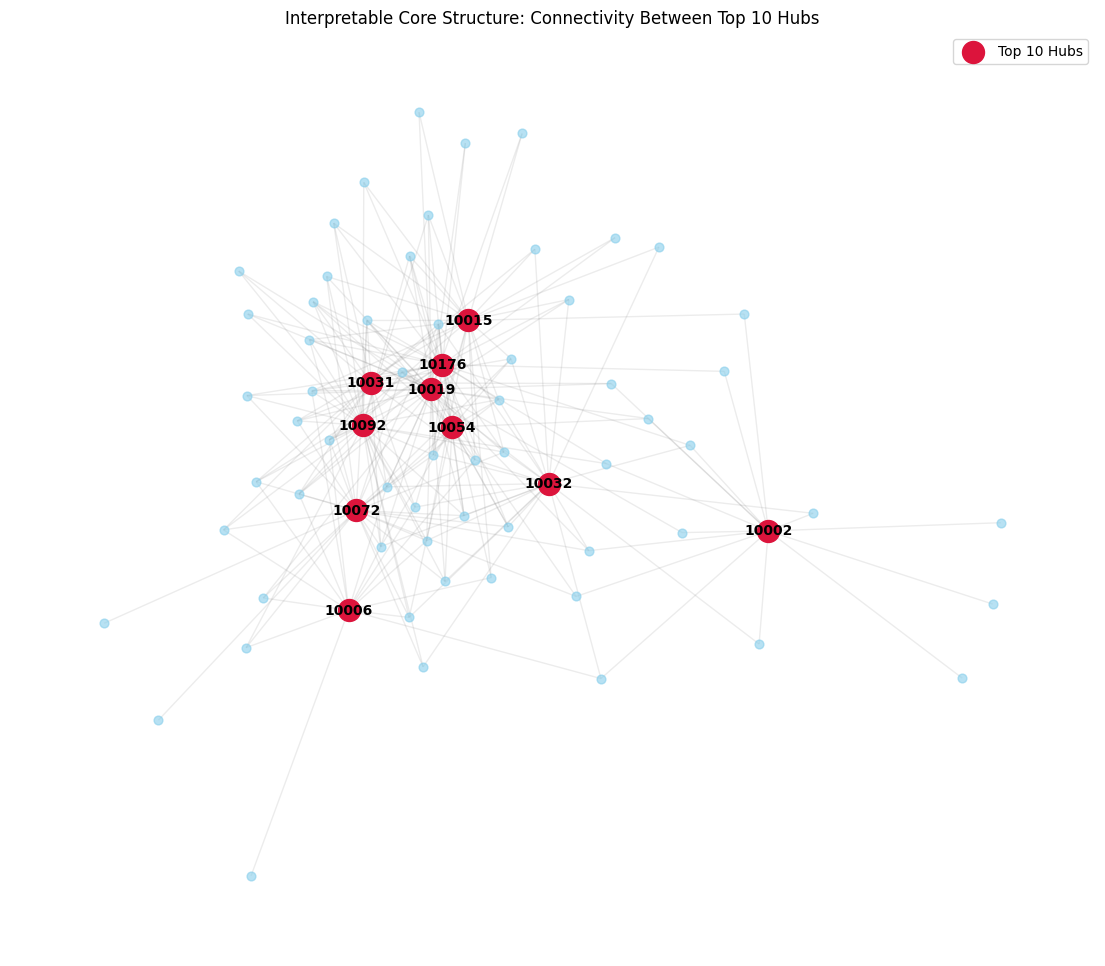

In [ ]:
top_hubs = [node for node, cent in top10_list]

# Collect neighbors for all top 10 hubs
all_sub_nodes = set(top_hubs)
for hub in top_hubs:
  # Add top 15 neighbors for each hub to keep the visual clean
  neighbors = sorted(G.neighbors(hub), key=lambda x: G.degree(x), reverse=True)[:15]
  all_sub_nodes.update(neighbors)

sub_G = G.subgraph(all_sub_nodes)

plt.figure(figsize=(14, 12))

# Use spring layout with adjusted repulsion (k) for multiple hubs
pos = nx.spring_layout(sub_G, k=0.2, iterations=100, seed=42)

# Regular neighbors in blue, Hubs in red
regular_nodes = [n for n in sub_G.nodes() if n not in top_hubs]
nx.draw_networkx_nodes(sub_G, pos, nodelist=regular_nodes, node_size=40, node_color='skyblue', alpha=0.6)
nx.draw_networkx_nodes(sub_G, pos, nodelist=top_hubs, node_size=250, node_color='crimson', label='Top 10 Hubs')

# Draw edges with low alpha to prevent clutter
nx.draw_networkx_edges(sub_G, pos, alpha=0.15, edge_color='gray')

# Label only the top hubs
labels = {node: str(node) for node in top_hubs}
nx.draw_networkx_labels(sub_G, pos, labels, font_size=10, font_weight='bold')

plt.title("Interpretable Core Structure: Connectivity Between Top 10 Hubs")
plt.legend(scatterpoints=1)
plt.axis('off')
plt.show()

*   **The Giant Component**: The network consists of three connected components, with a dominant Largest Connected Component (LCC) containing 10,980 of 10,984 nodes (~99.96%). This indicates that the projected interaction network is almost entirely connected at a structural level. The near-total dominance of the LCC suggests a highly cohesive interaction topology, which is typical of large-scale social media networks after temporal aggregation.
*   **Peripheral Groups and Isolated Nodes**: The remaining components are very small and correspond to weakly connected interaction patterns, likely arising from rare or isolated user-subreddit interactions that do not integrate into the main network structure.
*   **Implications for TGN**: The dominance of a single connected component indicates that the underlying interaction structure is highly cohesive, which provides favorable conditions for temporal models such as TGN, where information can propagate across most of the network over time through sequential interactions.

# Community Detection

In this section, we use the Louvain algorithm to partition the network into communities. This helps uncover the functional structure of the Reddit graph, identifying groups of users and subreddits that form dense interaction clusters.

In [ ]:
partition = community_louvain.best_partition(G)
modularity = community_louvain.modularity(partition, G)

communities = {}
for node, comm_id in partition.items():
  if comm_id not in communities:
    communities[comm_id] = []
  communities[comm_id].append(node)

num_communities = len(communities)
comm_sizes = [len(c) for c in communities.values()]

print(f"Number of communities detected: {num_communities}")
print(f"Modularity: {modularity:.4f}")

Number of communities detected: 15
Modularity: 0.4301


*   **Modularity Score**: A high modularity (typically > 0.3) indicates that the network has a clear community structure. In this dataset, we see how users gravitate toward specific subreddits, forming dense clusters.

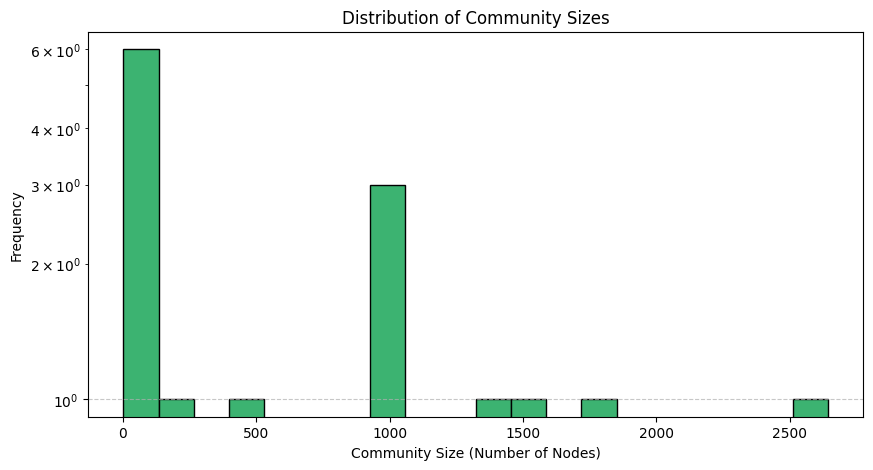

Community sizes from smallest to largest: 2, 2, 11, 12, 15, 37, 234, 499, 935, 984, 1046, 1356, 1473, 1734, 2644


In [ ]:
plt.figure(figsize=(10, 5))
plt.hist(comm_sizes, bins=20, color='mediumseagreen', edgecolor='black')
plt.title('Distribution of Community Sizes')
plt.xlabel('Community Size (Number of Nodes)')
plt.ylabel('Frequency')
plt.yscale('log')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(f"Community sizes from smallest to largest: {', '.join(map(str, sorted(comm_sizes)))}")

This histogram (in log scale) reveals the "clumpiness" of the Reddit network:
*   **Uneven communities:** Community sizes are heterogeneous, ranging from very small groups to a dominant community of over 2,700 nodes.
*   **Mega-Communities:** There is a distinct outlier on the far right. A community with over 2,700 nodes.
*   **Functional Clusters:** The bars in the middle (size 1,000–1,500) suggest several medium-sized interest groups that are large enough to be cohesive but specialized enough to remain distinct from the main mass.

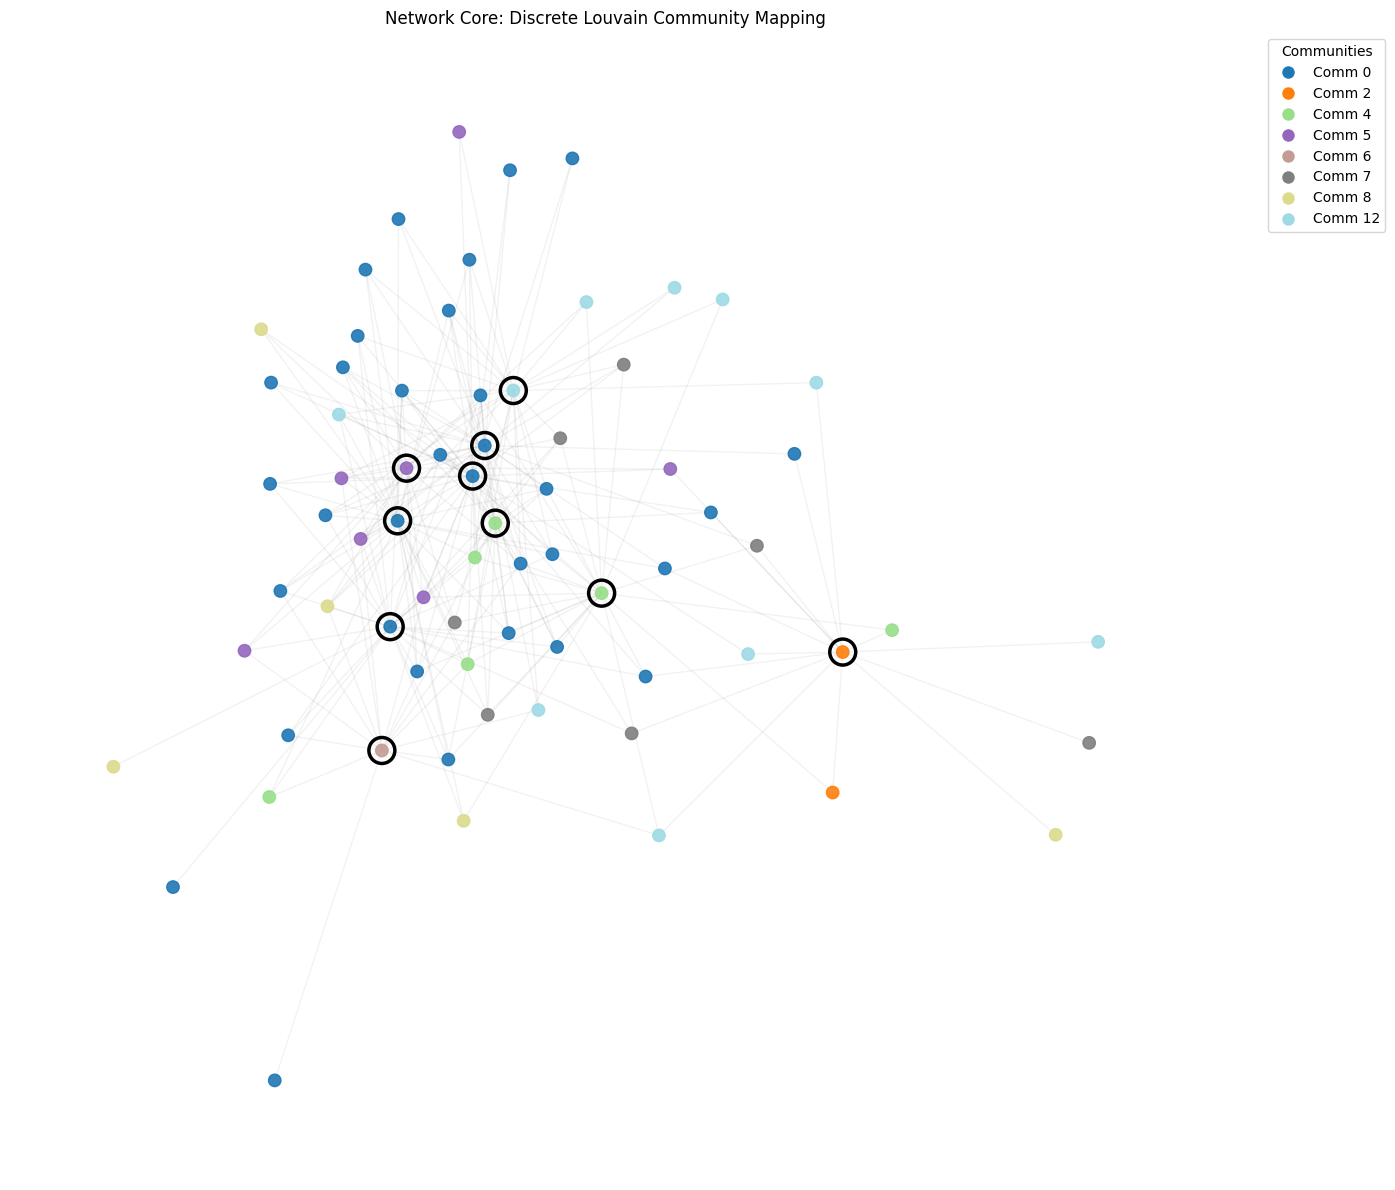

In [ ]:
# We reuse the sub_G and partition from before
sub_nodes = list(sub_G.nodes())
sub_partition = {node: partition[node] for node in sub_nodes}

unique_comms = sorted(list(set(sub_partition.values())))
num_unique_comms = len(unique_comms)

cmap = plt.get_cmap('tab20', num_unique_comms)
comm_to_idx = {comm: i for i, comm in enumerate(unique_comms)}
node_colors = [comm_to_idx[sub_partition[n]] for n in sub_nodes]

plt.figure(figsize=(14, 12))
pos = nx.spring_layout(sub_G, k=0.2, iterations=100, seed=42)

nodes_draw = nx.draw_networkx_nodes(
    sub_G, pos,
    node_size=80,
    node_color=node_colors,
    cmap=cmap,
    alpha=0.9
)

nx.draw_networkx_nodes(sub_G, pos, nodelist=top_hubs, node_size=350,
                       node_color='none', edgecolors='black', linewidths=2.5)

nx.draw_networkx_edges(sub_G, pos, alpha=0.1, edge_color='gray')

# Create a legend with discrete markers instead of a continuous colorbar
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label=f'Comm {c}',
           markerfacecolor=cmap(i), markersize=10)
    for i, c in enumerate(unique_comms)
]

plt.legend(handles=legend_elements, title="Communities", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("Network Core: Discrete Louvain Community Mapping")
plt.axis('off')
plt.tight_layout()
plt.show()

This visualization shows the "skeletal" structure of the network (top 10 hubs and their closest neighbors) colored by their detected community:
*   **Hub Diversity:** Notice that the top 10 hubs (nodes with black outlines) belong to several different communities (colors). The most central hub node belongs to one of several major communities rather than forming a community by itself.
*   **Bridges and Anchors:** Some communities are tightly clustered around a single hub, while others appear more spread out. In the context of the TGN, nodes within the same community exhibit denser interaction patterns and may therefore provide richer local context for temporal prediction models.

In [ ]:
stats = []
for cid, nodes_in_comm in communities.items():
  users = sum(n < 10000 for n in nodes_in_comm)
  subs = sum(n >= 10000 for n in nodes_in_comm)
  stats.append({
      'Community ID': cid,
      'Users': users,
      'Subreddits': subs,
      'User/Sub Ratio': round(users / max(subs, 1), 2)
  })

comm_df = pd.DataFrame(stats).sort_values(by='Users', ascending=False)
display(comm_df.style.background_gradient(cmap='YlGnBu', subset=['User/Sub Ratio']))

,Community ID,Users,Subreddits,User/Sub Ratio
1,5,2469,175,14.110000
4,4,1590,144,11.040000
0,0,1224,249,4.920000
3,12,1206,150,8.040000
2,2,1044,2,522.000000
7,8,850,134,6.340000
6,7,840,95,8.840000
5,6,496,3,165.330000
9,10,212,22,9.640000
11,13,34,3,11.330000


Community composition varies substantially across the network. Some communities contain hundreds of users interacting with only one or two subreddits, while others are distributed across hundreds of subreddits. This suggests that the Reddit interaction network contains both highly specialized regions and broader multi-community interaction ecosystems.

# Small-World and Scale-Free Analysis

In this section, we evaluate the global structural properties of the Reddit interaction graph. Specifically, we test whether the network exhibits "Small-World" properties (high clustering and low path lengths) and "Scale-Free" properties (power-law degree distribution).

## Small-World Analysis

In [ ]:
print("Calculating approximate small-world metrics...")

avg_clustering = nx.average_clustering(G)

lcc = max(nx.connected_components(G), key=len)
lcc_subgraph = G.subgraph(lcc)

sample_size = 1000
sample_nodes = random.sample(list(lcc_subgraph.nodes()), sample_size)

path_lengths = []

for node in sample_nodes:
  lengths = nx.single_source_shortest_path_length(lcc_subgraph, node)
  path_lengths.extend(lengths.values())

avg_path_length = np.mean(path_lengths)

n = G.number_of_nodes()
m = G.number_of_edges()
p = (2 * m) / (n * (n - 1))

G_random = nx.erdos_renyi_graph(n, p, seed=42)

random_clustering = nx.average_clustering(G_random)

random_path_length = np.log(n) / np.log(n * p)

sigma = (avg_clustering / random_clustering) / (
    avg_path_length / random_path_length
)

print(f"Average Clustering: {avg_clustering:.9f}")
print(f"Random Clustering: {random_clustering:.9f}")
print()
print(f"Approx. Average Path Length: {avg_path_length:.9f}")
print(f"Random Path Length (theoretical): {random_path_length:.9f}")
print()
print(f"Small-World Coefficient (Sigma): {sigma:.9f}")

if sigma > 1:
  print("\nConclusion: The network exhibits small-world characteristics.")
else:
  print("\nConclusion: No strong evidence of small-world structure.")

Calculating approximate small-world metrics...
Average Clustering: 0.000000000
Random Clustering: 0.001228907

Approx. Average Path Length: 3.597494536
Random Path Length (theoretical): 3.497684864

Small-World Coefficient (Sigma): 0.000000000

Conclusion: No strong evidence of small-world structure.


In [ ]:
print("Transitivity:", nx.transitivity(G))

Transitivity: 0


After sampling 1,000 source node, the Reddit interaction network exhibits an average shortest-path length of approximately 3.6, indicating a highly navigable structure. However, both the local clustering coefficient and global transitivity are exactly zero, reflecting the bipartite nature of the graph where interactions occur strictly between users and subreddits. As a result, triangle formation is structurally impossible, making classical small-world metrics inapplicable. The resulting small-world coefficient is therefore zero, not due to lack of connectivity, but due to the absence of triadic closure in the underlying network representation.

## Scale-Free Analysis

Calculating best minimal value for power law fit


Fitting xmin: 100%|██████████| 225/225 [00:00<00:00, 858.21it/s]


Estimated Alpha (Power Law Exponent): 2.2411
xmin: 30.0


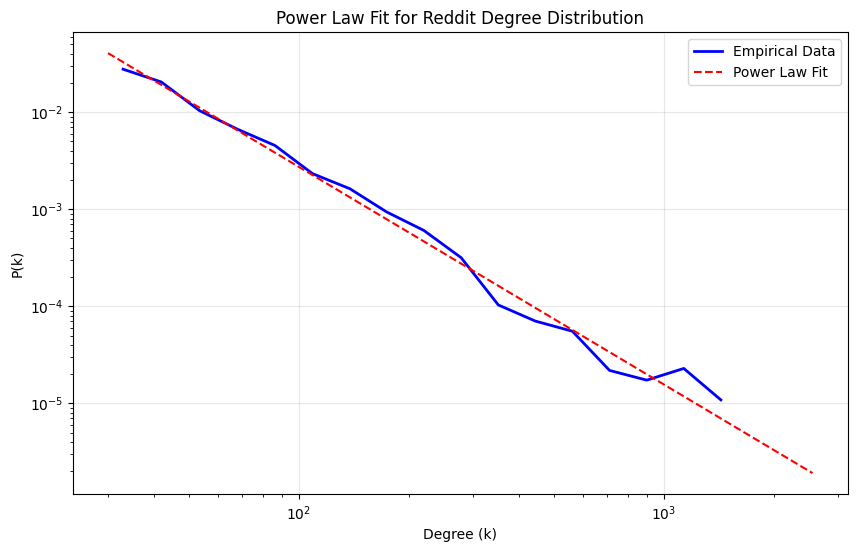

In [ ]:
# We already have "degrees" from previous cells
fit = powerlaw.Fit(degrees, discrete=True)

print(f"Estimated Alpha (Power Law Exponent): {fit.power_law.alpha:.4f}")
print(f"xmin: {fit.xmin}")

plt.figure(figsize=(10, 6))
fig = fit.plot_pdf(color='b', linewidth=2, label='Empirical Data')
fit.power_law.plot_pdf(color='r', linestyle='--', ax=fig, label='Power Law Fit')

plt.title("Power Law Fit for Reddit Degree Distribution")
plt.xlabel("Degree (k)")
plt.ylabel("P(k)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

A network is considered scale-free if its degree distribution follows a power law of the form $P(k) \sim k^{-\alpha}$, where a small number of nodes have very high degree while most nodes have low degree.

The fitted power-law model for the degree distribution yields:

*   **Power-law exponent**: $\alpha \approx 2.24$
*   **Lower bound**: $x_{min} = 30.0$

This indicates that the upper tail of the degree distribution follows a heavy-tailed pattern, where high-degree nodes are significantly more frequent than would be expected under a uniform or rapidly decaying distribution. In this regime, a small number of nodes act as hubs with substantially higher connectivity than the rest of the network.

However, the power-law behavior only holds above a threshold, meaning that the distribution is not uniform across all degrees. The lower-degree region does not follow the same scaling behavior, indicating that the network cannot be fully described by a single power-law model across its entire range.

# Network Resilience

Resilience analysis measures how a network maintains its connectivity when nodes are removed. Real-world scale-free networks typically exhibit a "robust yet fragile" property: they are highly resistant to random failures but extremely vulnerable to coordinated attacks on their hubs.

Simulating random failures and targeted attacks...


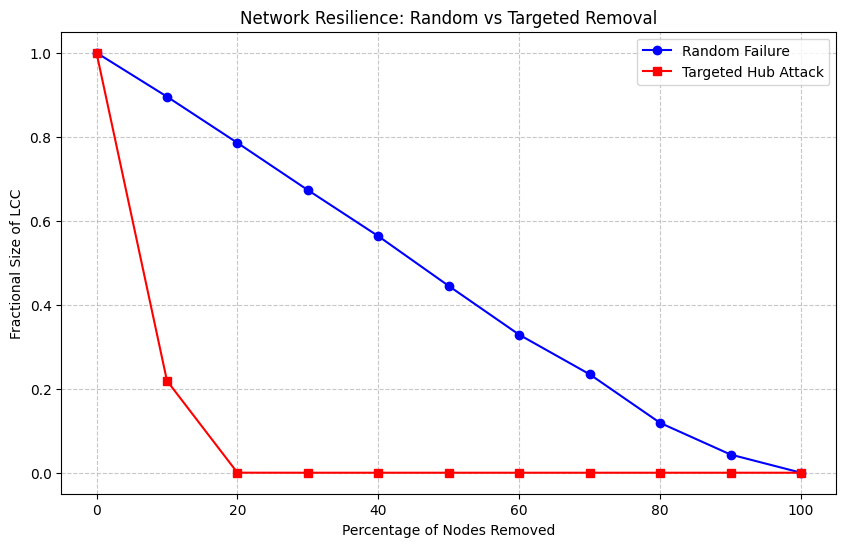

In [ ]:
def get_lcc_size(graph):
  if len(graph) == 0:
    return 0
  return len(max(nx.connected_components(graph), key=len))

def simulate_removal(graph, mode='random', steps=10):
  res = []
  temp_G = graph.copy()
  total_nodes = temp_G.number_of_nodes()
  num_to_remove = total_nodes // steps

  # Initial state
  res.append(get_lcc_size(temp_G) / total_nodes)

  for _ in range(steps):
    nodes_to_del = []
    if mode == 'random':
      nodes_to_del = random.sample(list(temp_G.nodes()), min(num_to_remove, temp_G.number_of_nodes()))
    elif mode == 'targeted':
      # Sort remaining nodes by degree
      deg_sorted = sorted(temp_G.degree(), key=lambda x: x[1], reverse=True)
      nodes_to_del = [n for n, d in deg_sorted[:num_to_remove]]

    temp_G.remove_nodes_from(nodes_to_del)
    res.append(get_lcc_size(temp_G) / total_nodes)
  return res

print("Simulating random failures and targeted attacks...")
fractions = np.linspace(0, 100, 11)
random_resilience = simulate_removal(G, mode='random')
targeted_resilience = simulate_removal(G, mode='targeted')

plt.figure(figsize=(10, 6))
plt.plot(fractions, random_resilience, marker='o', label='Random Failure', color='blue')
plt.plot(fractions, targeted_resilience, marker='s', label='Targeted Hub Attack', color='red')
plt.title('Network Resilience: Random vs Targeted Removal')
plt.xlabel('Percentage of Nodes Removed')
plt.ylabel('Fractional Size of LCC')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

Network resilience measures how the connectivity of a graph changes under progressive node removal. This provides insight into how dependent the network structure is on specific nodes.

*   **Random Failure (High Robustness)**: Under random node removal, the largest connected component decreases gradually. Even when a large fraction of nodes is removed, the network retains a substantial connected core. This indicates that most nodes are not structurally critical to maintaining global connectivity.

*   **Targeted Attack (High Fragility)**: When nodes are removed in descending order of degree, the largest connected component collapses rapidly. A small fraction of high-degree nodes has a disproportionate impact on network connectivity, and their removal leads to fast fragmentation of the graph.

This behavior reflects a core-periphery structure where connectivity is concentrated around a small subset of highly connected nodes.

# Temporal Network Analysis

While the static analysis revealed a scale-free, hub-dominated structure, it ignores *when* these interactions occurred. In this section, we analyze the temporal dynamics of the Reddit network to understand node activity evolution and interaction density over time.

/tmp/ipykernel_14038/3657439976.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_unique_nodes = df.groupby('day').apply(lambda x: len(set(x['src']) | set(x['dst'])))


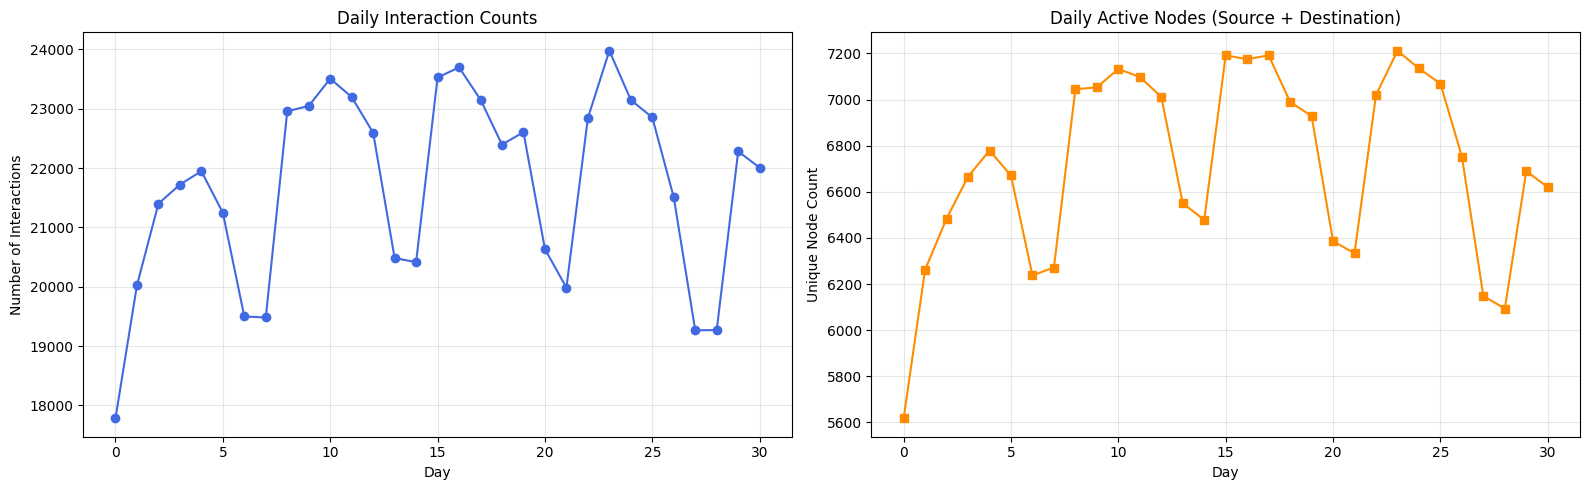

Average daily interactions: 21691.84
Average daily active nodes: 6719.32


In [ ]:
# 1. Interaction Counts over Time (Daily and Weekly)
df['timestamp_dt'] = pd.to_datetime(df['t'], unit='s')
df['week'] = ((df['t'] - df['t'].min()) / (3600 * 24 * 7)).astype(int)

daily_activity = df.groupby('day').size()
weekly_activity = df.groupby('week').size()

# 2. Node Activity Evolution
# Track how many unique nodes are active each day
daily_unique_nodes = df.groupby('day').apply(lambda x: len(set(x['src']) | set(x['dst'])))

plt.figure(figsize=(16, 5))

plt.subplot(1, 2, 1)
plt.plot(daily_activity.index, daily_activity.values, marker='o', color='royalblue', label='Daily Interactions')
plt.title('Daily Interaction Counts')

plt.xlabel('Day')
plt.ylabel('Number of Interactions')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(daily_unique_nodes.index, daily_unique_nodes.values, marker='s', color='darkorange', label='Unique Nodes')
plt.title('Daily Active Nodes (Source + Destination)')
plt.xlabel('Day')
plt.ylabel('Unique Node Count')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Average daily interactions: {daily_activity.mean():.2f}")
print(f"Average daily active nodes: {daily_unique_nodes.mean():.2f}")

## Temporal Degree Growth

In a static graph, a hub has a fixed degree. In a temporal network, hubs "grow." We will track the cumulative degree growth of the top 3 most central nodes identified earlier (10032, 10019, 10072) to see if their dominance is consistent throughout the month.

Node 10032 growth rate (slope): 0.0008
Node 10019 growth rate (slope): 0.0005
Node 10072 growth rate (slope): 0.0005


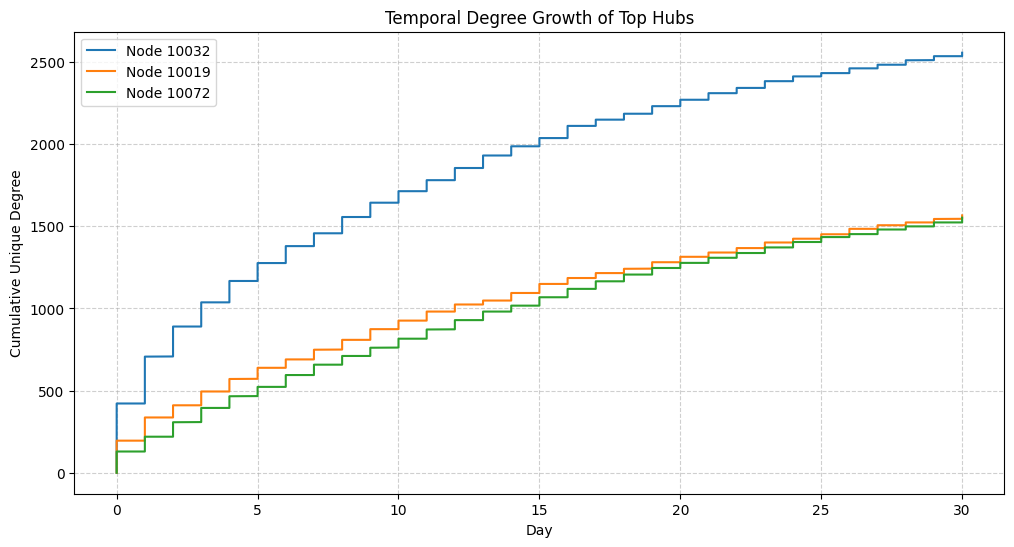

In [ ]:
top_3_hubs = [10032, 10019, 10072]

plt.figure(figsize=(12, 6))

for hub in top_3_hubs:
  # Filter interactions involving this hub
  hub_interacts = df[(df['src'] == hub) | (df['dst'] == hub)].copy()
  hub_interacts = hub_interacts.sort_values('t')

  # Cumulative unique neighbors over time
  # Note: This is an approximation of 'degree(t)'
  hub_interacts['neighbor'] = hub_interacts.apply(
    lambda x: x['dst'] if x['src'] == hub else x['src'], axis=1
  )

  # Track first time each neighbor is seen
  hub_interacts['is_first_contact'] = ~hub_interacts['neighbor'].duplicated()
  hub_interacts['cumulative_degree'] = hub_interacts['is_first_contact'].cumsum()

  hub_interacts['cumulative_degree_norm'] = hub_interacts['cumulative_degree'] / hub_interacts['cumulative_degree'].max()

  x = hub_interacts['t'].values
  y = hub_interacts['cumulative_degree'].values

  slope = np.polyfit(x, y, 1)[0]
  print(f"Node {hub} growth rate (slope): {slope:.4f}")

  plt.plot(hub_interacts['day'], hub_interacts['cumulative_degree'], label=f'Node {hub}')

plt.title('Temporal Degree Growth of Top Hubs')
plt.xlabel('Day')
plt.ylabel('Cumulative Unique Degree')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

The temporal evolution of node connectivity reveals how structural hubs emerge and accumulate influence over time in the interaction network.

The cumulative unique degree of the top hubs increases monotonically throughout the observation period, indicating continuous acquisition of new neighbors rather than short bursts of activity. This suggests that hub status is reinforced gradually through repeated exposure in the interaction stream.

The growth trajectories are approximately linear, indicating a stable interaction regime without abrupt structural shifts. Among the selected nodes, one hub consistently exhibits a higher growth rate, maintaining its dominance across the entire temporal window.

These results demonstrate that hub prominence is not a static property but a dynamic process driven by continuous interaction accumulation. Rather than sudden popularity spikes, the network exhibits persistent reinforcement of high-degree nodes over time.

This supports the use of temporal models such as TGN, which explicitly encode interaction history and allow node representations to evolve according to their growth trajectories.

# Dynamic Link Prediction with TGN

## Original Author's Comments & Link to Repositories

*"[...] However, [this code] is not
directly comparable to the results reported by the TGN paper since a
slightly different evaluation setup is used here.  
In particular, predictions in the same batch are made in parallel, i.e.
predictions for interactions later in the batch have no access to any
information whatsoever about previous interactions in the same batch.
On the contrary, when sampling node neighborhoods for interactions later in
the batch, the TGN paper code has access to previous interactions in the
batch.  
While both approaches are correct, together with the authors of the paper we
decided to present this version here as it is more realistic and a better
test bed for future methods."*

<br>

---

<br>

Implementation adapted from PyTorch Geometric Temporal Graph Network (TGN) example which can be found at following repo: https://github.com/pyg-team/pytorch_geometric

## High-level explanation of TGN

Temporal Graph Networks (TGN) are designed to model graphs where interactions happen over time rather than existing as a fixed structure. Instead of treating edges as static, TGN processes the network as a continuous stream of events, where each interaction updates the representation of the involved nodes.

The central idea is that each node maintains a form of memory that summarizes its past interactions. Whenever a new interaction occurs, this memory is updated, allowing the model to keep track of how a node's behavior evolves over time. This makes TGN fundamentally different from static graph neural networks, which only operate on a fixed snapshot of the graph.

When predicting a future interaction (for example, whether a user will interact with a subreddit), TGN does not rely only on the current graph structure. Instead, it combines three sources of information:

the node's historical memory (what has happened to it over time),
its recent neighborhood interactions (who it has interacted with recently),
and the temporal context of the interaction (when it happened).

These signals are combined using a graph neural network that produces updated node embeddings, which are then used for downstream tasks such as link prediction.

In this way, TGN can be understood as a system that continuously updates node representations as new events arrive, allowing it to model evolving behavior patterns rather than static relationships.

## TGN Implementation

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# For small datasets, we can put the whole dataset on GPU and thus avoid
# expensive memory transfer costs for mini-batches:
data = data.to(device)

### Splitting & Loading

In [ ]:
train_data, val_data, test_data = data.train_val_test_split(
    val_ratio=0.15, test_ratio=0.15
)

train_loader = TemporalDataLoader(
    train_data,
    batch_size=200,
    neg_sampling_ratio=1.0,
)
val_loader = TemporalDataLoader(
    val_data,
    batch_size=200,
    neg_sampling_ratio=1.0,
)
test_loader = TemporalDataLoader(
    test_data,
    batch_size=200,
    neg_sampling_ratio=1.0,
)
neighbor_loader = LastNeighborLoader(data.num_nodes, size=10, device=device)

### Classes

In [ ]:
class GraphAttentionEmbedding(torch.nn.Module):
  def __init__(self, in_channels, out_channels, msg_dim, time_enc):
    super().__init__()
    self.time_enc = time_enc
    edge_dim = msg_dim + time_enc.out_channels
    self.conv = TransformerConv(in_channels, out_channels // 2, heads=2,
                                dropout=0.1, edge_dim=edge_dim)

  def forward(self, x, last_update, edge_index, t, msg):
    rel_t = last_update[edge_index[0]] - t
    rel_t_enc = self.time_enc(rel_t.to(x.dtype))
    edge_attr = torch.cat([rel_t_enc, msg], dim=-1)
    return self.conv(x, edge_index, edge_attr)

class LinkPredictor(torch.nn.Module):
  def __init__(self, in_channels):
    super().__init__()
    self.lin_src = Linear(in_channels, in_channels)
    self.lin_dst = Linear(in_channels, in_channels)
    self.lin_final = Linear(in_channels, 1)

  def forward(self, z_src, z_dst):
    h = self.lin_src(z_src) + self.lin_dst(z_dst)
    h = h.relu()
    return self.lin_final(h)

### Critical Definitions

In [ ]:
memory_dim = time_dim = embedding_dim = 100

memory = TGNMemory(
  data.num_nodes,
  data.msg.size(-1),
  memory_dim,
  time_dim,
  message_module=IdentityMessage(data.msg.size(-1), memory_dim, time_dim),
  aggregator_module=LastAggregator(),
).to(device)

gnn = GraphAttentionEmbedding(
  in_channels=memory_dim,
  out_channels=embedding_dim,
  msg_dim=data.msg.size(-1),
  time_enc=memory.time_enc,
).to(device)

link_pred = LinkPredictor(in_channels=embedding_dim).to(device)

optimizer = torch.optim.Adam(
  set(memory.parameters()) | set(gnn.parameters())
  | set(link_pred.parameters()), lr=0.0001)
criterion = torch.nn.BCEWithLogitsLoss()

# Helper vector to map global node indices to local ones.
assoc = torch.empty(data.num_nodes, dtype=torch.long, device=device)

### Training & Testing Functions

In [ ]:
def train():
  memory.train()
  gnn.train()
  link_pred.train()

  memory.reset_state()  # Start with a fresh memory.
  neighbor_loader.reset_state()  # Start with an empty graph.

  total_loss = 0
  for batch in train_loader:
    optimizer.zero_grad()
    batch = batch.to(device)

    n_id, edge_index, e_id = neighbor_loader(batch.n_id)
    assoc[n_id] = torch.arange(n_id.size(0), device=device)

    # Get updated memory of all nodes involved in the computation.
    z, last_update = memory(n_id)
    z = gnn(z, last_update, edge_index, data.t[e_id].to(device),
            data.msg[e_id].to(device))
    pos_out = link_pred(z[assoc[batch.src]], z[assoc[batch.dst]])
    neg_out = link_pred(z[assoc[batch.src]], z[assoc[batch.neg_dst]])

    loss = criterion(pos_out, torch.ones_like(pos_out))
    loss += criterion(neg_out, torch.zeros_like(neg_out))

    # Update memory and neighbor loader with ground-truth state.
    memory.update_state(batch.src, batch.dst, batch.t, batch.msg)
    neighbor_loader.insert(batch.src, batch.dst)

    loss.backward()
    optimizer.step()
    memory.detach()
    total_loss += float(loss) * batch.num_events

  return total_loss / train_data.num_events

@torch.no_grad()
def test(loader):
  memory.eval()
  gnn.eval()
  link_pred.eval()

  torch.manual_seed(12345)  # Ensure deterministic sampling across epochs.

  aps, aucs = [], []
  for batch in loader:
    batch = batch.to(device)

    n_id, edge_index, e_id = neighbor_loader(batch.n_id)
    assoc[n_id] = torch.arange(n_id.size(0), device=device)

    z, last_update = memory(n_id)
    z = gnn(z, last_update, edge_index, data.t[e_id].to(device),
            data.msg[e_id].to(device))
    pos_out = link_pred(z[assoc[batch.src]], z[assoc[batch.dst]])
    neg_out = link_pred(z[assoc[batch.src]], z[assoc[batch.neg_dst]])

    y_pred = torch.cat([pos_out, neg_out], dim=0).sigmoid().cpu()
    y_true = torch.cat(
        [torch.ones(pos_out.size(0)),
          torch.zeros(neg_out.size(0))], dim=0)

    aps.append(average_precision_score(y_true, y_pred))
    aucs.append(roc_auc_score(y_true, y_pred))

    memory.update_state(batch.src, batch.dst, batch.t, batch.msg)
    neighbor_loader.insert(batch.src, batch.dst)
  return float(torch.tensor(aps).mean()), float(torch.tensor(aucs).mean())

### Main Loop Through Epochs

In [ ]:
for epoch in range(1, 11):
  loss = train()
  print(f'Epoch: {epoch:02d}, Loss: {loss:.4f}')
  val_ap, val_auc = test(val_loader)
  test_ap, test_auc = test(test_loader)
  print(f'Val AP: {val_ap:.4f}, Val AUC: {val_auc:.4f}')
  print(f'Test AP: {test_ap:.4f}, Test AUC: {test_auc:.4f}')

Epoch: 01, Loss: 0.3332
Val AP: 0.9858, Val AUC: 0.9856
Test AP: 0.9852, Test AUC: 0.9848
Epoch: 02, Loss: 0.3256
Val AP: 0.9857, Val AUC: 0.9855
Test AP: 0.9847, Test AUC: 0.9843
Epoch: 03, Loss: 0.3228
Val AP: 0.9857, Val AUC: 0.9854
Test AP: 0.9848, Test AUC: 0.9844
Epoch: 04, Loss: 0.3197
Val AP: 0.9858, Val AUC: 0.9855
Test AP: 0.9850, Test AUC: 0.9846
Epoch: 05, Loss: 0.3183
Val AP: 0.9857, Val AUC: 0.9855
Test AP: 0.9852, Test AUC: 0.9849
Epoch: 06, Loss: 0.3163
Val AP: 0.9858, Val AUC: 0.9856
Test AP: 0.9855, Test AUC: 0.9851
Epoch: 07, Loss: 0.3148
Val AP: 0.9857, Val AUC: 0.9855
Test AP: 0.9852, Test AUC: 0.9848
Epoch: 08, Loss: 0.3132
Val AP: 0.9854, Val AUC: 0.9853
Test AP: 0.9849, Test AUC: 0.9844
Epoch: 09, Loss: 0.3108
Val AP: 0.9856, Val AUC: 0.9853
Test AP: 0.9852, Test AUC: 0.9848
Epoch: 10, Loss: 0.3088
Val AP: 0.9857, Val AUC: 0.9854
Test AP: 0.9851, Test AUC: 0.9847


The model achieves consistently high performance across validation and test sets, with stable AP and AUC values around 0.985. This indicates that the temporal memory mechanism effectively captures interaction patterns in the dataset, allowing accurate prediction of future links based on historical node activity and neighborhood structure.

The small gap between training loss reduction and stable evaluation metrics suggests that the model converges quickly and does not exhibit significant overfitting under the current evaluation setup.

# Project Conclusion

This project combined classical network analysis with Temporal Graph Networks (TGN) to study a large-scale Reddit interaction network.

The static analysis revealed a sparse but highly connected network dominated by a small number of hub nodes. Community detection showed a clear modular structure, while resilience analysis demonstrated that the network is robust to random failures but vulnerable to targeted removal of highly connected nodes. Although the network exhibits heavy-tailed degree distributions, its bipartite structure prevents the formation of triangles, making traditional small-world characteristics largely inapplicable.

The temporal analysis showed that influential hubs emerge through steady accumulation of interactions rather than sudden bursts of activity. This highlights the importance of considering not only who is connected, but also when interactions occur.

To capture these temporal dynamics, a Temporal Graph Network was applied for link prediction. By maintaining node memories and updating representations as new events arrive, TGN achieved strong predictive performance, with AP and AUC scores around 0.985.

Overall, the results show that while static graph analysis provides valuable insight into network structure, temporal models such as TGN are better suited for understanding and predicting behavior in evolving interaction networks.